In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from bs4 import BeautifulSoup

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report
from sklearn.naive_bayes import MultinomialNB
from  sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer

import joblib


In [2]:
!pip install spacy

In [8]:
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 4.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [9]:
import spacy
# !python -m spacy download en_core_web_lg
nlp = spacy.load("en_core_web_lg")

In [10]:
df = pd.read_csv('fake reviews dataset.csv')
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [11]:
df['label'].value_counts()

,count
label,
CG,20216
OR,20216


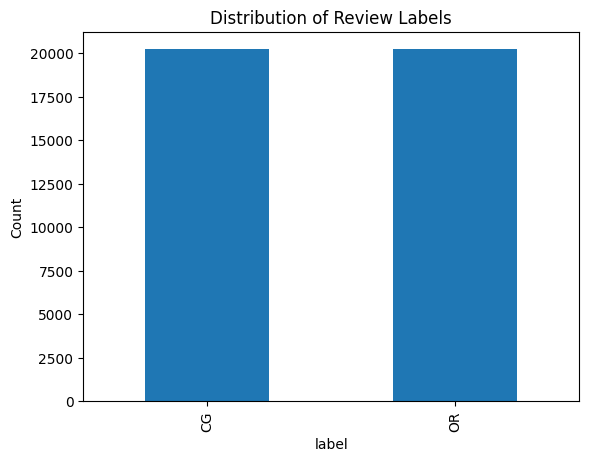

In [12]:
label_counts = df['label'].value_counts()

plt.figure()
label_counts.plot(kind='bar')
plt.title('Distribution of Review Labels')
plt.ylabel('Count')
plt.show()

In [13]:
df['encoded_label'] = df['label'].map({'CG' : 1, 'OR': 0})
df.head()

,category,rating,label,text_,encoded_label
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor...",1
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I...",1
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,1
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",1
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,1


# Preprocessing Pipeline
- remove the stop words
- lemmatization
- remove punctuations
- remove urls
- remove HTML tagging
- remove additional spaces

In [ ]:
def preprocess(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r'\s+', ' ', text).strip()

    doc = nlp(text)

    filtered_tokens = []
    for token in doc:
        if not token.is_stop and not token.is_punct:
            filtered_tokens.append(token.lemma_)

    return " ".join(filtered_tokens)

In [15]:
sen = preprocess(df.iloc[1,3])
sen

'love great upgrade original couple year'

In [16]:
df['processed_text'] = df['text_'].apply(preprocess)
df.head()


,category,rating,label,text_,encoded_label,processed_text
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor...",1,love sturdy comfortable love it!very pretty
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I...",1,love great upgrade original couple year
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,1,pillow save love look feel pillow
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",1,miss information use great product price
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,1,nice set good quality set month


# Filtering out empty rows

In [17]:
df = df[df['processed_text'].str.strip() != ""].copy()

In [18]:
df['processed_text'].head()

,processed_text
0,love sturdy comfortable love it!very pretty
1,love great upgrade original couple year
2,pillow save love look feel pillow
3,miss information use great product price
4,nice set good quality set month


# TF-IDF

In [27]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)
X = tfidf.fit_transform(df['processed_text'])
y = df['encoded_label']

joblib.dump(tfidf, "vectorizer.joblib")

['vectorizer.joblib']

# Spliting the data and modeling


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2022,
    stratify=y
)

In [21]:
model_svc = SVC()
model_svc.fit(X_train, y_train)
y_pred = model_svc.predict(X_test)

print("SVC")
print(classification_report(y_test, y_pred))

joblib.dump(model_svc, "svc.joblib")

SVC
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      4044
           1       0.90      0.86      0.88      4037

    accuracy                           0.88      8081
   macro avg       0.88      0.88      0.88      8081
weighted avg       0.88      0.88      0.88      8081



['svc.joblib']

In [22]:
clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

joblib.dump(clf, "logistic_reg.joblib")

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      4044
           1       0.88      0.86      0.87      4037

    accuracy                           0.87      8081
   macro avg       0.87      0.87      0.87      8081
weighted avg       0.87      0.87      0.87      8081



['logistic_reg.joblib']

In [23]:
clf = MultinomialNB()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("MultinomialNB")
print(classification_report(y_test, y_pred))

joblib.dump(clf, "multinomial.joblib")

MultinomialNB
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      4044
           1       0.86      0.83      0.85      4037

    accuracy                           0.85      8081
   macro avg       0.85      0.85      0.85      8081
weighted avg       0.85      0.85      0.85      8081



['multinomial.joblib']

In [24]:
clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred))

joblib.dump(clf, "random_forest.joblib")

Random Forest
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      4044
           1       0.87      0.81      0.84      4037

    accuracy                           0.85      8081
   macro avg       0.85      0.85      0.85      8081
weighted avg       0.85      0.85      0.85      8081



['random_forest.joblib']

In [25]:
from sklearn.linear_model import SGDClassifier  # import model

clf = SGDClassifier(loss='hinge', random_state=42)  # SVM-like model

clf.fit(X_train, y_train)  # train

y_pred = clf.predict(X_test)  # predict

print("SGDClassifier (Hinge - SVM Style)")
print(classification_report(y_test, y_pred))

joblib.dump(clf, "sgd_classifier.joblib")

SGDClassifier (Hinge - SVM Style)
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      4044
           1       0.89      0.85      0.87      4037

    accuracy                           0.87      8081
   macro avg       0.87      0.87      0.87      8081
weighted avg       0.87      0.87      0.87      8081



['sgd_classifier.joblib']